# Income classification

# Adult Income Dataset

| Column Name | Description | Values / Type |
|-------------|-------------|---------------|
| age | Age of an individual | Integer > 0 |
| workclass | Employment status of an individual | Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked |
| fnlwgt | Final weight representing the estimated number of people the census entry represents | Integer > 0 |
| education | Highest level of education achieved | Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool |
| education-num | Highest education level in numerical form | Integer > 0 |
| marital-status | Marital status of an individual | Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse |
| occupation | General occupation type | Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces |
| relationship | Relationship to other household members | Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried |
| race | Race of an individual | White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black |
| sex | Biological sex | Male, Female |
| capital-gain | Capital gains | Integer ≥ 0 |
| capital-loss | Capital losses | Integer ≥ 0 |
| hours-per-week | Hours worked per week | Continuous |
| native-country | Country of origin | United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands |
| income (Label) | Annual income class (Target) | <=50K, >50K |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math

warnings.filterwarnings("ignore")
sns.set_style(style= "darkgrid")
plt.rcParams["figure.figsize"] = (16, 8)

In [2]:
df = pd.read_csv("income_evaluation.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
df.isnull().sum()

age                0
 workclass         0
 fnlwgt            0
 education         0
 education-num     0
 marital-status    0
 occupation        0
 relationship      0
 race              0
 sex               0
 capital-gain      0
 capital-loss      0
 hours-per-week    0
 native-country    0
 income            0
dtype: int64

In [7]:
for column in df.columns:
    df.rename(
        columns= {
            f"{column}" :f"{column.lstrip()}"
        },
        inplace= True
    )

In [8]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [12]:
def get_categoric(dataFrame = df):
    categoric = dataFrame.select_dtypes(include= "object")
    categoric_columns = categoric.columns

    return categoric_columns

In [13]:
def get_numeric(dataFrame = df):
    numeric = dataFrame.select_dtypes(include= "int")
    numeric_columns = numeric.columns

    return numeric_columns

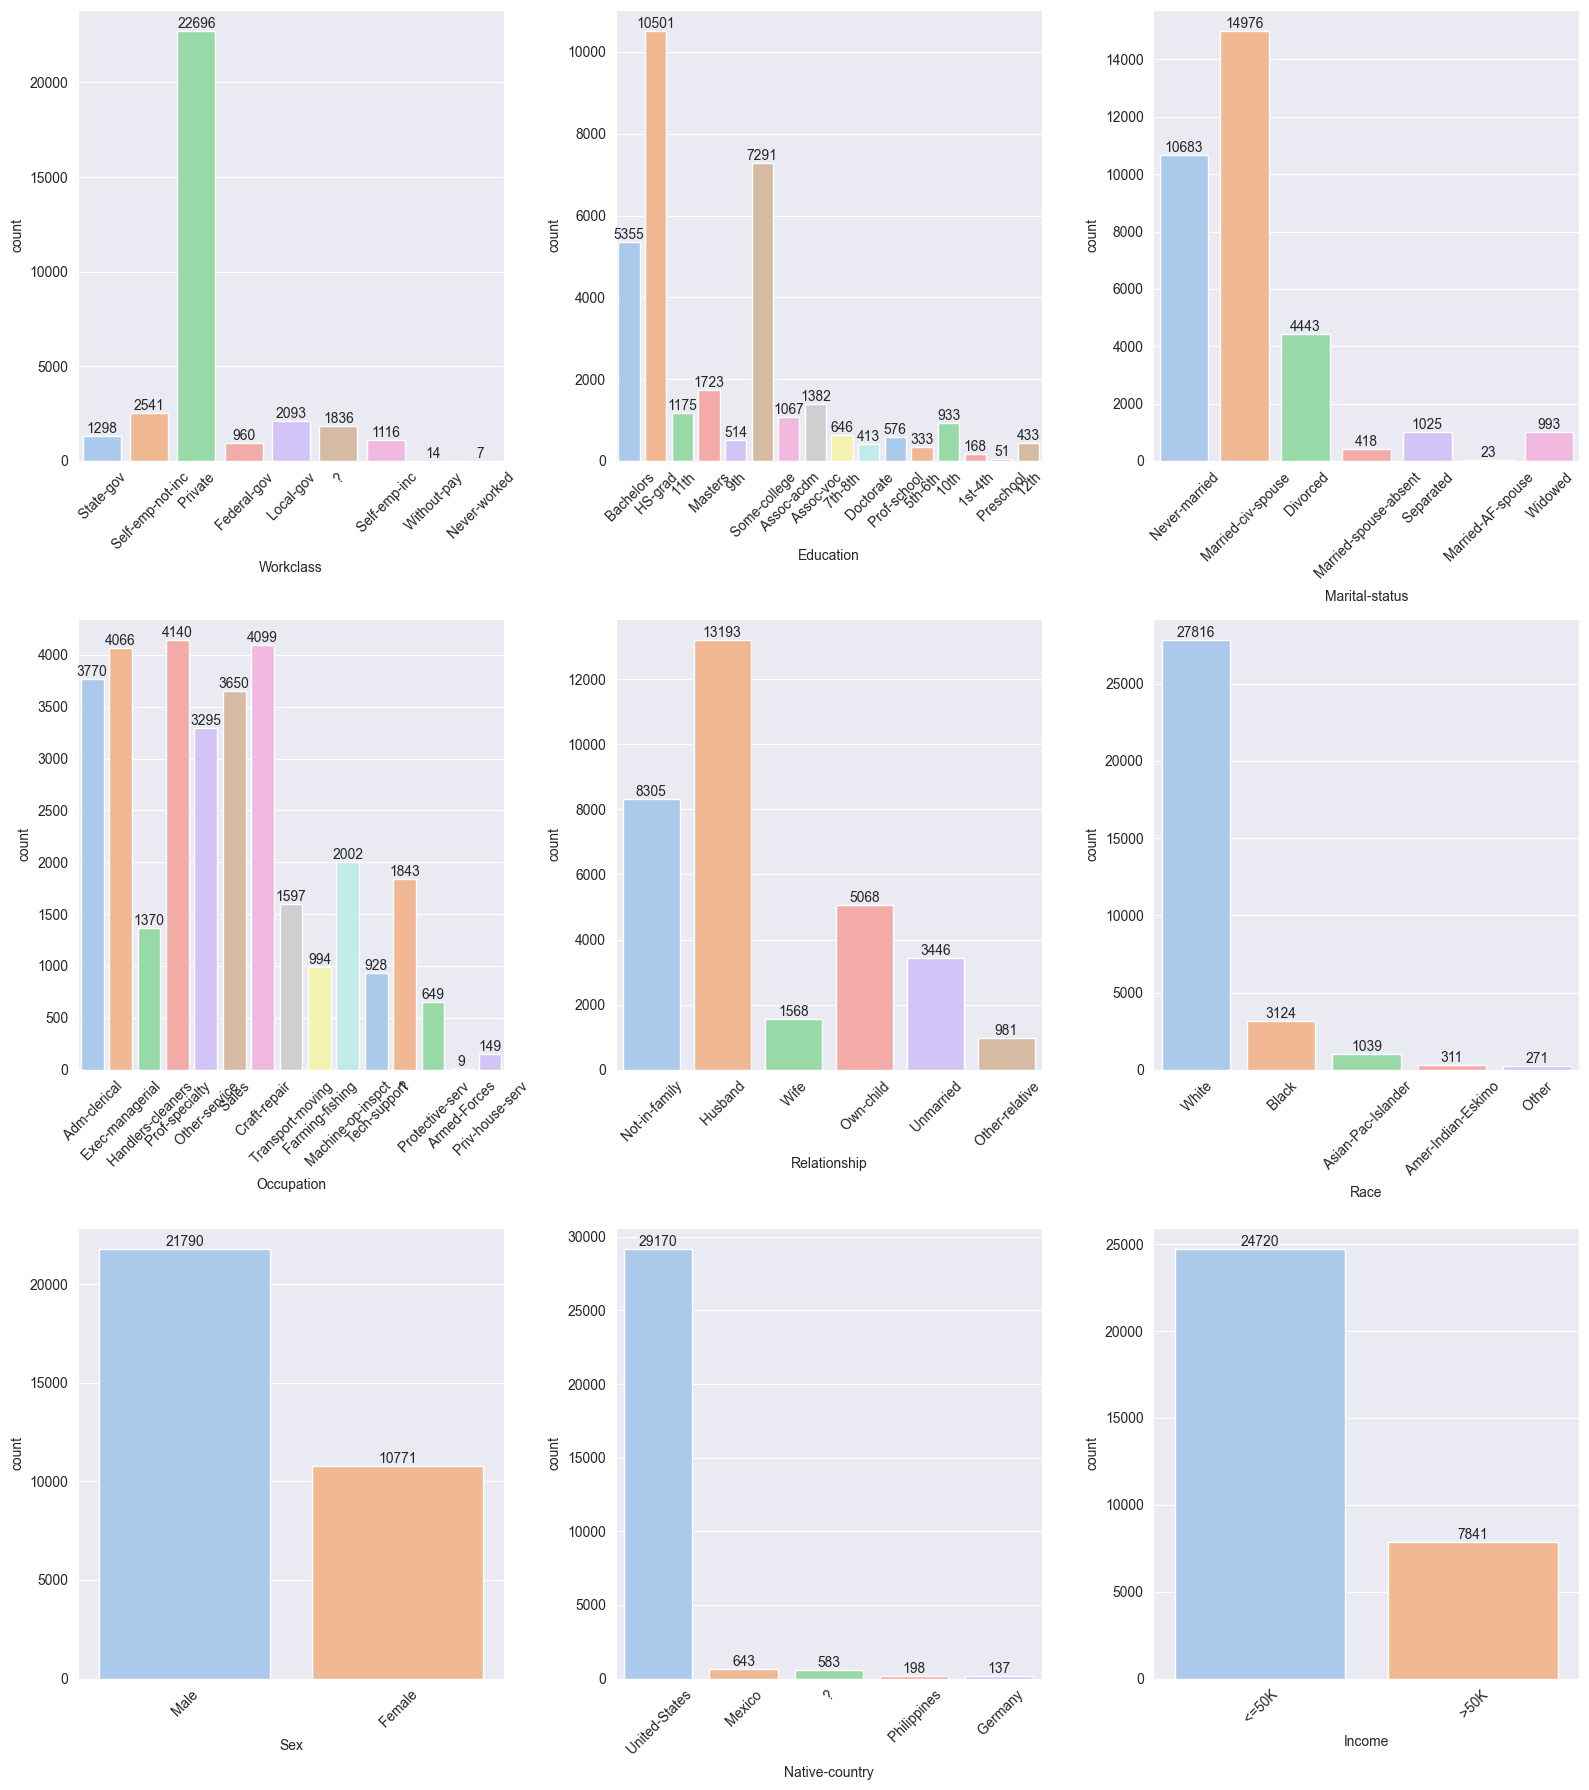

In [14]:
categoric = get_categoric()

col = 3
row = math.ceil((len(categoric) / col))

fig, ax = plt.subplots(row, col, figsize = (16, row * 6))
ax = ax.ravel()

for idx, column in enumerate(categoric):
    if column == "native-country":
        
        top5 = df[column].value_counts().head(5).index

        axis = sns.countplot(
            data= df[df[column].isin(top5)],
            x= column,
            order= top5,
            ax= ax[idx],
            palette= "pastel"
        )
    else:
        axis = sns.countplot(
            data= df,
            x= column,
            ax= ax[idx],
            palette= "pastel"
        )

    for container in axis.containers:
        axis.bar_label(container)

    axis.set_xlabel(f"{column.capitalize()}")
    axis.set_xticks(axis.get_xticks())
    axis.set_xticklabels(axis.get_xticklabels(), rotation = 45)

plt.tight_layout()
plt.show()

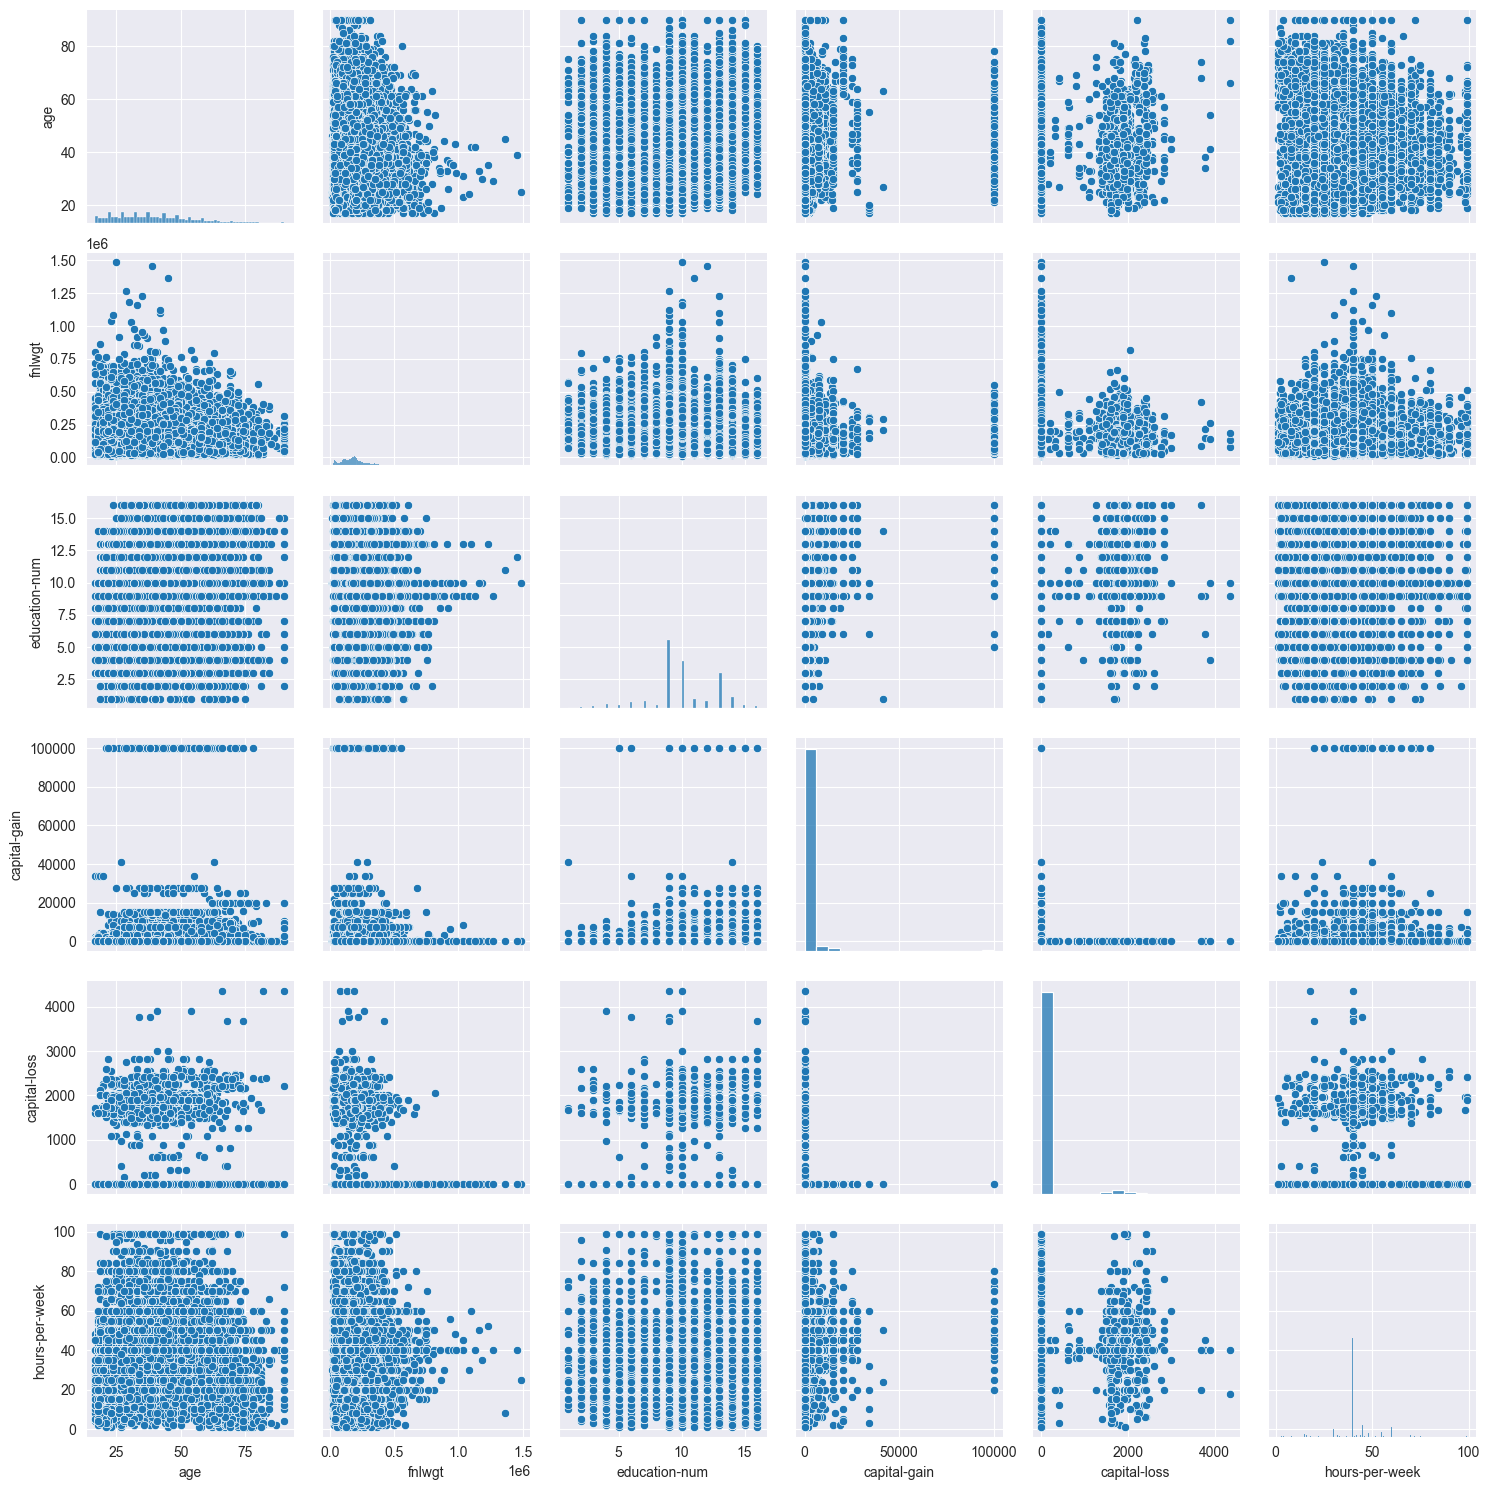

In [15]:
sns.pairplot(df)

plt.tight_layout()
plt.show()

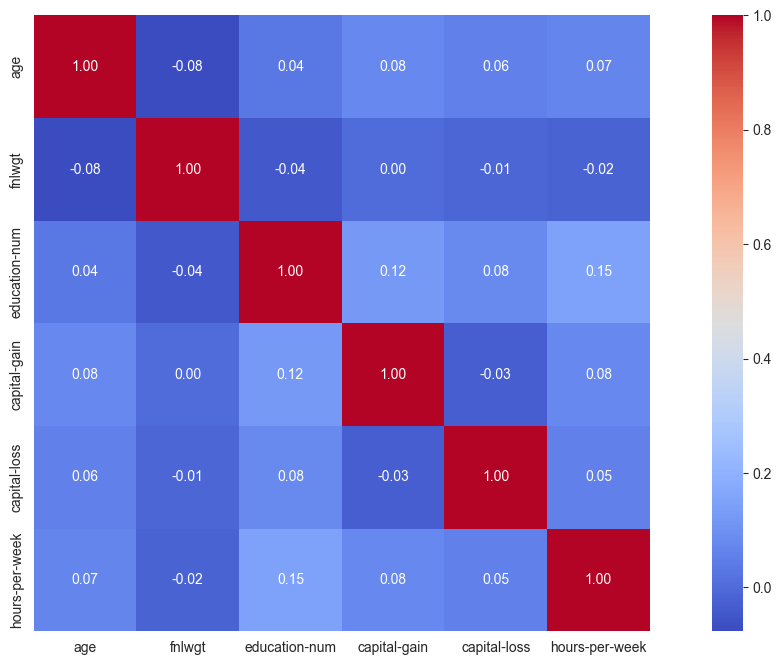

In [19]:
corr = df.corr(numeric_only= True)

sns.heatmap(corr, cmap= "coolwarm", square= True, annot= True, fmt= ".2f")

plt.show()

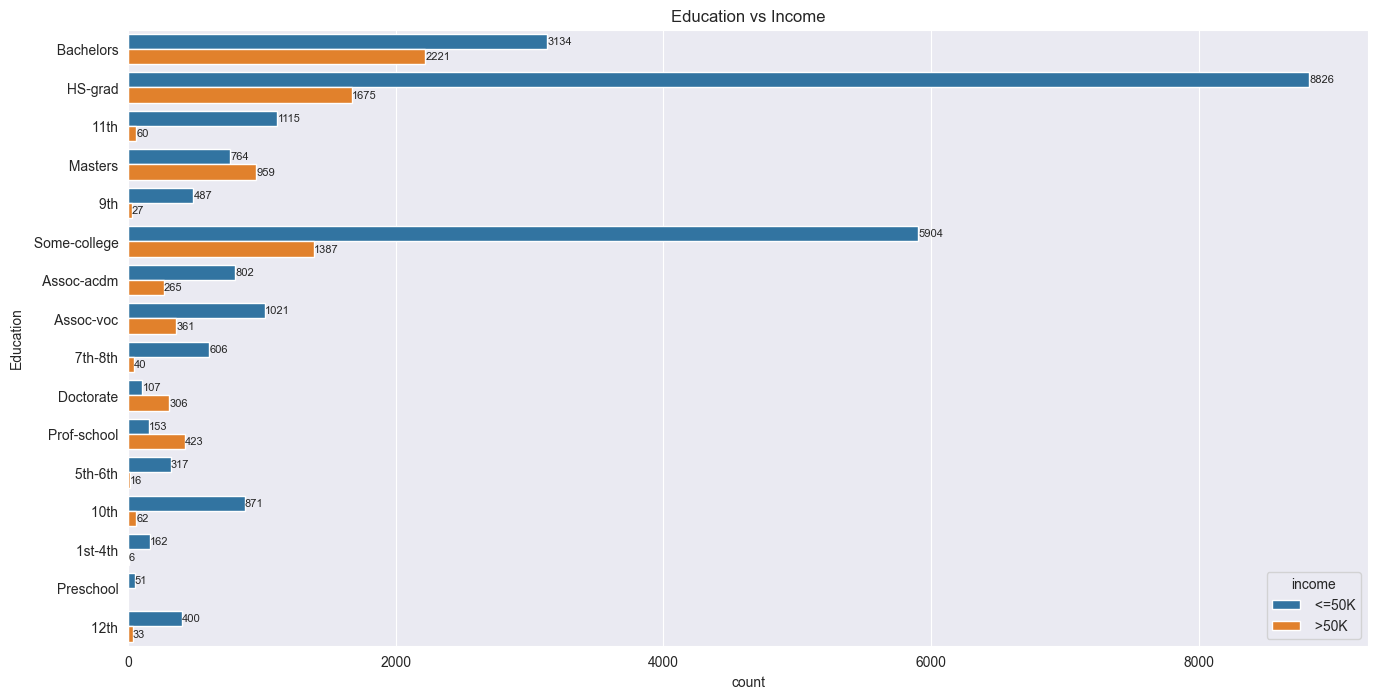

In [49]:
ax = sns.countplot(
    data= df,
    y= "education",
    hue= "income"
)

for container in ax.containers:
    ax.bar_label(container, fontsize = 8)

plt.title("Education vs Income")
plt.ylabel("Education")

plt.show()

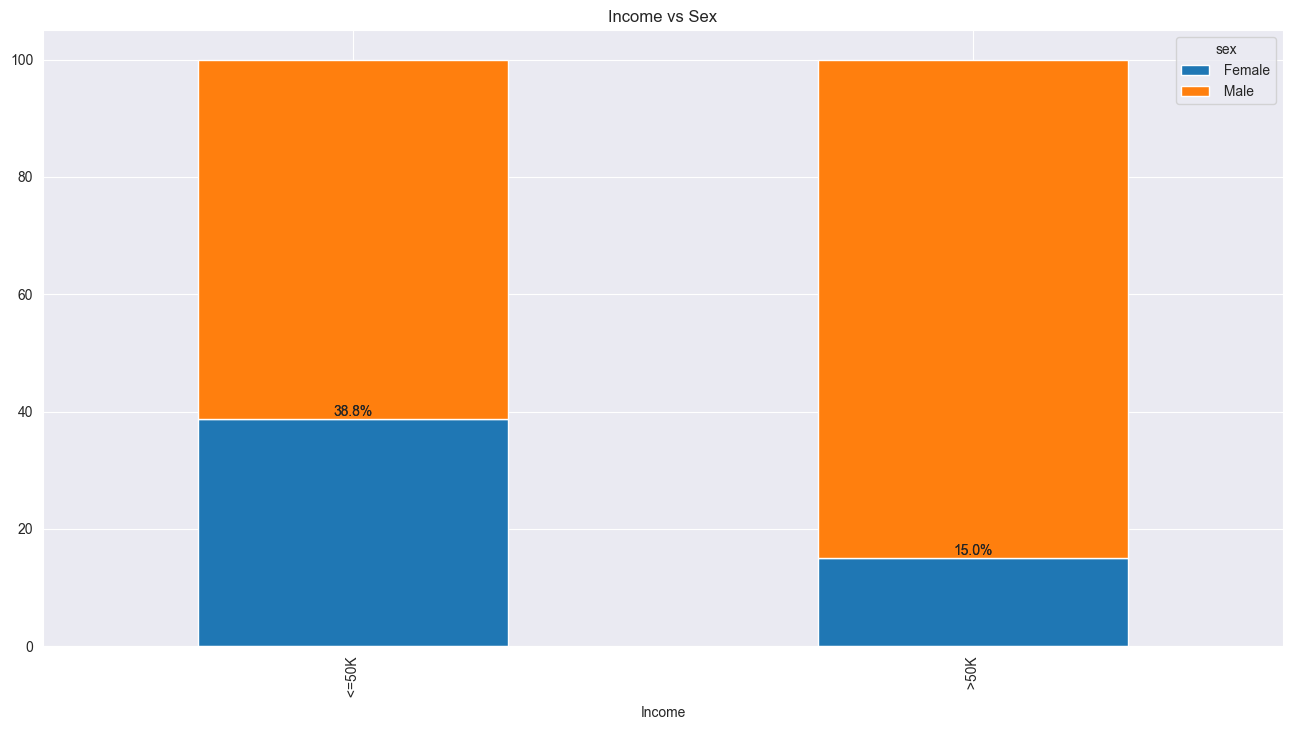

In [65]:
ct = pd.crosstab(df["income"], df["sex"], normalize= "index") * 100

ax = ct.plot(kind= "bar", stacked= True)

for container in ax.containers:
    ax.bar_label(ax.containers[0], fmt= "%.1f%%")

ax.set_xlabel("Income")


plt.title("Income vs Sex")
plt.show()

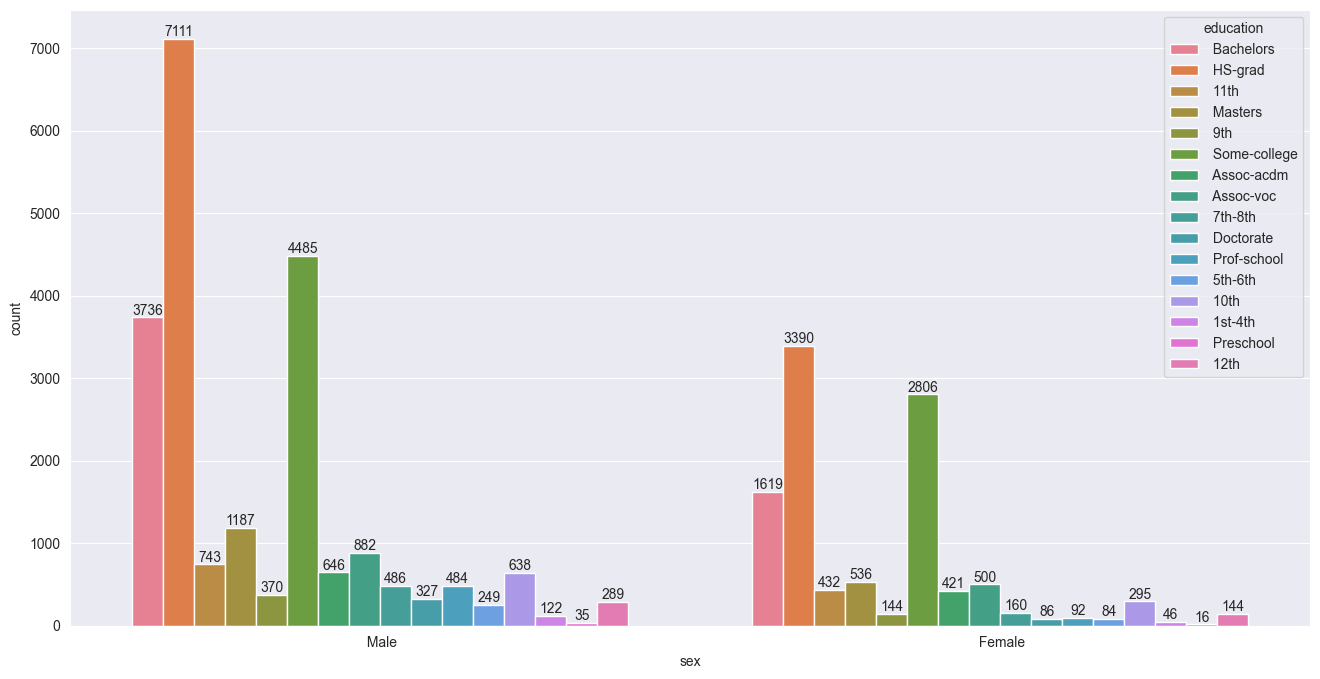

In [71]:
ax = sns.countplot(
    data= df,
    x= "sex",
    hue= "education"
)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [72]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
df.drop(, axis= 1, inplace= True)

KeyError: "['fnlwgt'] not found in axis"